In [1]:
import pandas as pd

# Load the CSV
csv_file = "data/replay.csv"
df = pd.read_csv(csv_file)

# Show the first 5 rows
df.head()


,time,file,packets,bytes,duration,bps,mbps,pps,flows,fps,flow_packets,non_flow_packets,packets_successful,packets_failed,packets_truncated,packets_retried_enobufs,packets_retried_eagain,order,date_time
0,22:25:41,0001-abbott.allinahealth.pcap,47,4866,0.002311,2105581.9,16.84,20337.51,2.0,865.42,47.0,0.0,47,0,0,0,0,1,2026-02-21 22:25:41
1,22:25:41,0002-abbott-glucometer.allina.2.pcap,40,3452,0.001962,1759429.1,14.07,20387.35,2.0,1019.36,40.0,0.0,40,0,0,0,0,2,2026-02-21 22:25:41
2,22:25:42,0003-abbott-glucometer.allina.pcap,367,239384,0.018308,13075376.8,104.60,20045.88,2.0,109.24,367.0,0.0,367,0,0,0,0,3,2026-02-21 22:25:42
3,22:25:42,0004-southshore_lantronix_Abbott_Blood_Glucose...,15725,1340695,0.786208,1705267.5,13.64,20001.06,20.0,25.43,10727.0,4998.0,15725,0,0,0,0,4,2026-02-21 22:25:42
4,22:25:42,0005-PP1_TCP_ABB.capability.pcapng,19,1456,0.000910,1600000.0,12.80,20879.12,2.0,2197.80,19.0,0.0,19,0,0,0,0,5,2026-02-21 22:25:42


In [2]:
# Suppose you want to drop 'flow_packets', 'non_flow_packets', 'packets_retried_enobufs'
cols_to_drop = ['time', 'file']

df = df.drop(columns=cols_to_drop)

In [3]:
# Basic info about columns and types
df.info()

# Summary statistics for numeric columns
print(df.describe())

# Check for missing values
df.isna().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2132 entries, 0 to 2131
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   packets                  2132 non-null   int64  
 1   bytes                    2132 non-null   int64  
 2   duration                 2132 non-null   float64
 3   bps                      2132 non-null   float64
 4   mbps                     2132 non-null   float64
 5   pps                      2132 non-null   float64
 6   flows                    2112 non-null   float64
 7   fps                      2112 non-null   float64
 8   flow_packets             2112 non-null   float64
 9   non_flow_packets         2112 non-null   float64
 10  packets_successful       2132 non-null   int64  
 11  packets_failed           2132 non-null   int64  
 12  packets_truncated        2132 non-null   int64  
 13  packets_retried_enobufs  2132 non-null   int64  
 14  packets_retried_eagain  

packets                     0
bytes                       0
duration                    0
bps                         0
mbps                        0
pps                         0
flows                      20
fps                        20
flow_packets               20
non_flow_packets           20
packets_successful          0
packets_failed              0
packets_truncated           0
packets_retried_enobufs     0
packets_retried_eagain      0
order                       0
date_time                   0
dtype: int64

In [4]:
missing_any = df[df.isna().any(axis=1)]
print(f"Rows with any missing values: {len(missing_any)}")
missing_any


Rows with any missing values: 20


,packets,bytes,duration,bps,mbps,pps,flows,fps,flow_packets,non_flow_packets,packets_successful,packets_failed,packets_truncated,packets_retried_enobufs,packets_retried_eagain,order,date_time
1302,2,84,0.000064,1312500.0,10.50,31250.00,NaN,NaN,NaN,NaN,2,0,0,0,0,1303,2026-02-21 23:29:41
1478,100,6516,0.004968,1311594.2,10.49,20128.82,NaN,NaN,NaN,NaN,100,0,0,0,0,1479,2026-02-21 23:41:51
1550,3,180,0.000103,1747572.8,13.98,29126.21,NaN,NaN,NaN,NaN,3,0,0,0,0,1555,2026-02-21 23:47:46
1551,2,176,0.000065,2707692.3,21.66,30769.23,NaN,NaN,NaN,NaN,2,0,0,0,0,1556,2026-02-21 23:47:46
1552,1,144,0.000002,72000000.0,576.00,500000.00,NaN,NaN,NaN,NaN,1,0,0,0,0,1557,2026-02-21 23:47:46
1824,1334,56028,0.066658,840529.2,6.72,20012.60,NaN,NaN,NaN,NaN,1334,0,0,0,0,1829,2026-02-21 23:56:13
1915,77,4620,0.003811,1212280.2,9.69,20204.67,NaN,NaN,NaN,NaN,77,0,0,0,0,1921,2026-02-21 23:58:19
1938,1000,277409,0.049958,5552844.3,44.42,20016.81,NaN,NaN,NaN,NaN,1000,0,0,0,0,1944,2026-02-21 23:58:27
1941,19999,2559888,0.999909,2560120.9,20.48,20000.82,NaN,NaN,NaN,NaN,19999,0,0,0,0,1947,2026-02-21 23:58:32
1965,10,600,0.000469,1279317.6,10.23,21321.96,NaN,NaN,NaN,NaN,10,0,0,0,0,1972,2026-02-21 23:58:42


In [5]:
df.fillna(0, inplace=True)

# Check for missing values
df.isna().sum()


packets                    0
bytes                      0
duration                   0
bps                        0
mbps                       0
pps                        0
flows                      0
fps                        0
flow_packets               0
non_flow_packets           0
packets_successful         0
packets_failed             0
packets_truncated          0
packets_retried_enobufs    0
packets_retried_eagain     0
order                      0
date_time                  0
dtype: int64

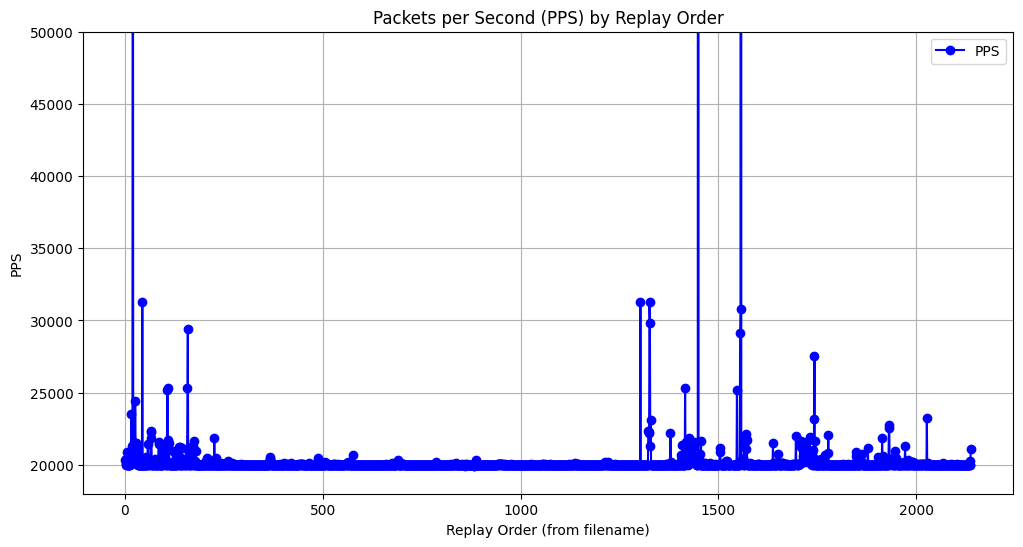

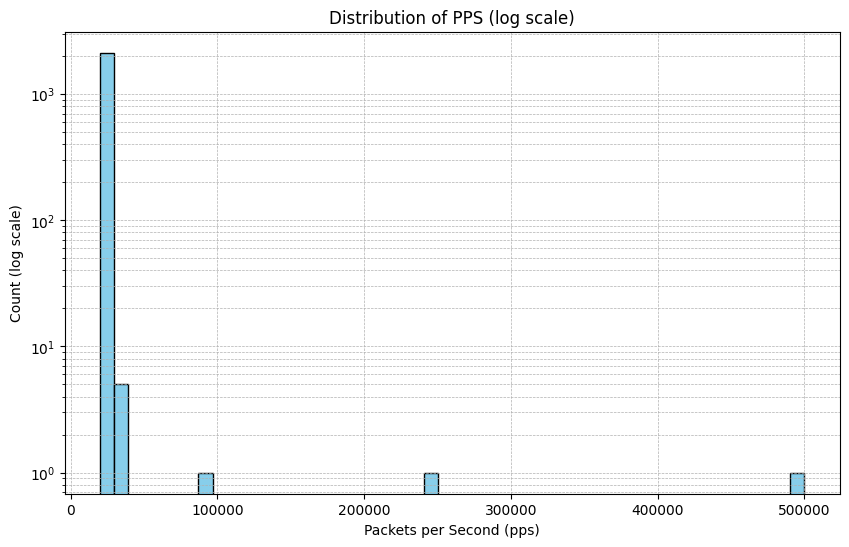

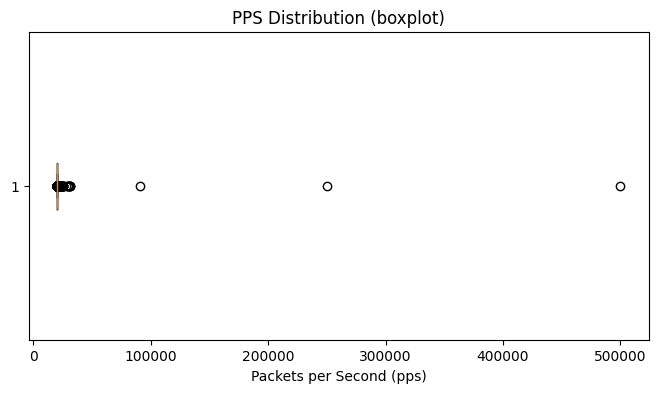

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))
plt.plot(df['order'], df['pps'], marker='o', linestyle='-', color='blue', label='PPS')

plt.title('Packets per Second (PPS) by Replay Order')
plt.xlabel('Replay Order (from filename)')
plt.ylabel('PPS')
plt.ylim(18000, 50000)  # Zoom y-axis to [0, 30000]
plt.grid(True)
plt.legend()
plt.show()

plt.figure(figsize=(10,6))
plt.hist(df['pps'], bins=50, color='skyblue', edgecolor='black', log=True)
plt.title('Distribution of PPS (log scale)')
plt.xlabel('Packets per Second (pps)')
plt.ylabel('Count (log scale)')
plt.grid(True, which="both", ls="--", lw=0.5)
plt.show()

plt.figure(figsize=(8,4))
plt.boxplot(df['pps'], vert=False)
plt.title('PPS Distribution (boxplot)')
plt.xlabel('Packets per Second (pps)')
plt.show()


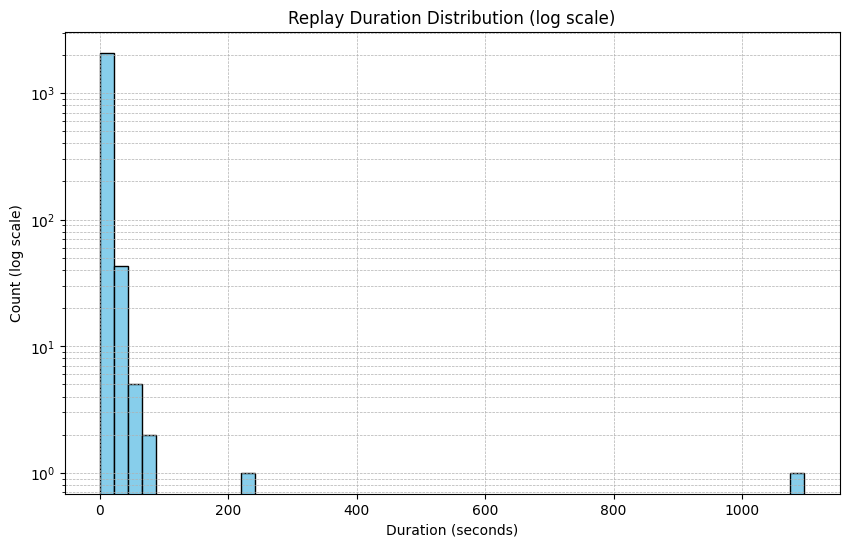

In [14]:
import matplotlib.pyplot as plt
import numpy as np

plt.figure(figsize=(10,6))
plt.hist(df['duration'], bins=50, color='skyblue', edgecolor='black', log=True)
plt.title('Replay Duration Distribution (log scale)')
plt.xlabel('Duration (seconds)')
plt.ylabel('Count (log scale)')
plt.grid(True, which="both", ls="--", lw=0.5)
plt.show()


In [11]:
# Total duration of all PCAP replays
total_duration = df['duration'].sum()
print(f"Total duration: {total_duration:.2f} seconds")

total_minutes = total_duration / 60
total_hours = total_duration / 3600

print(f"Total duration: {total_duration:.2f} seconds")
print(f"Total duration: {total_minutes:.2f} minutes")
print(f"Total duration: {total_hours:.2f} hours")

print(f"Total number of packets: {df['packets'].sum():,} packets")

Total duration: 5673.71 seconds
Total duration: 5673.71 seconds
Total duration: 94.56 minutes
Total duration: 1.58 hours
Total number of packets: 113,551,724 packets


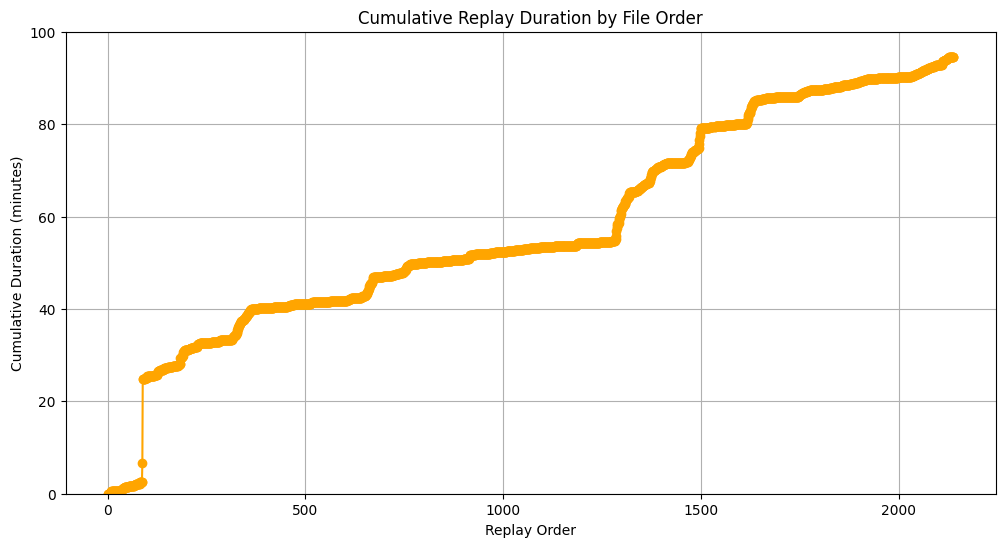

In [19]:
import matplotlib.pyplot as plt

# Convert cumulative duration to minutes
cumulative_minutes = df['duration'].cumsum() / 60  # seconds → minutes

plt.figure(figsize=(12,6))
plt.plot(df['order'], cumulative_minutes, marker='o', linestyle='-', color='orange')
plt.title('Cumulative Replay Duration by File Order')
plt.xlabel('Replay Order')
plt.ylabel('Cumulative Duration (minutes)')
plt.ylim(0, 100)  # Zoom y-axis to 0–100 minutes
plt.grid(True)
plt.savefig("data/cumulative_replay_duration.png", dpi=300, bbox_inches='tight')
plt.show()


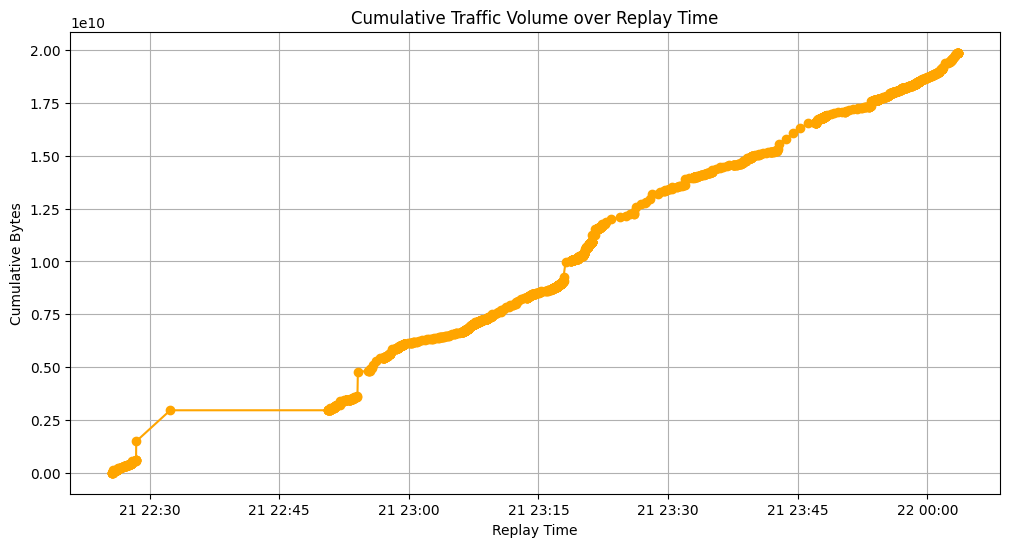

In [20]:
# Make sure date_time is datetime type
df['date_time'] = pd.to_datetime(df['date_time'])

plt.figure(figsize=(12,6))
plt.plot(df['date_time'], df['bytes'].cumsum(), marker='o', linestyle='-', color='orange')
plt.title('Cumulative Traffic Volume over Replay Time')
plt.xlabel('Replay Time')
plt.ylabel('Cumulative Bytes')
plt.grid(True)
plt.show()
